# Project 3 — Neural Network From Scratch

## Overview
We implement a fully-connected neural network using **only NumPy** — no PyTorch, no TensorFlow. This forces us to understand every mathematical operation that deep learning frameworks perform internally.

**Architecture:**
```
Input(784) → Dense(128) → ReLU → Dense(64) → ReLU → Dense(10) → Softmax
```

## 1. Theory — Forward Pass

### Neuron and Layer
A single layer computes a **linear transformation** followed by a **non-linear activation**:
$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = f\left(\mathbf{z}^{(l)}\right)$$

where $\mathbf{W}^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$, $\mathbf{b}^{(l)} \in \mathbb{R}^{n_l}$.

### Activation Functions

**ReLU** (hidden layers):
$$\text{ReLU}(z) = \max(0, z)$$
$$\text{ReLU}'(z) = \mathbb{1}[z > 0]$$

**Softmax** (output layer for multi-class):
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

Softmax converts raw logits into a probability distribution over $C$ classes.

## 2. Theory — Loss & Backpropagation

### Cross-Entropy Loss
For $C$ classes with one-hot target $\mathbf{y}$ and predicted probabilities $\hat{\mathbf{p}}$:
$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log \hat{p}_c$$

For a batch of $N$ examples:
$$\mathcal{L}_{batch} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log \hat{p}_{ic}$$

### Backpropagation — Chain Rule
To train the network we need $\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}}$ for each layer. By the chain rule:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}} \cdot \frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{W}^{(l)}}$$

Define the **error signal** $\boldsymbol{\delta}^{(l)} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}}$.

**Output layer** (Softmax + Cross-Entropy — the derivative simplifies beautifully):
$$\boldsymbol{\delta}^{(L)} = \hat{\mathbf{p}} - \mathbf{y}$$

**Hidden layer** $l$:
$$\boldsymbol{\delta}^{(l)} = \left(\mathbf{W}^{(l+1)T} \boldsymbol{\delta}^{(l+1)}\right) \odot f'\left(\mathbf{z}^{(l)}\right)$$

**Weight gradient**:
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \boldsymbol{\delta}^{(l)} \cdot \mathbf{a}^{(l-1)T}$$

### Gradient Descent Update
$$\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \cdot \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}}$$

where $\eta$ is the learning rate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_theme(style='whitegrid')
print('NumPy version:', np.__version__)

NumPy version: 1.26.4


## 3. Load MNIST

Loading MNIST (may take a moment on first run)...
Train: (8000, 784) | Test: (2000, 784)


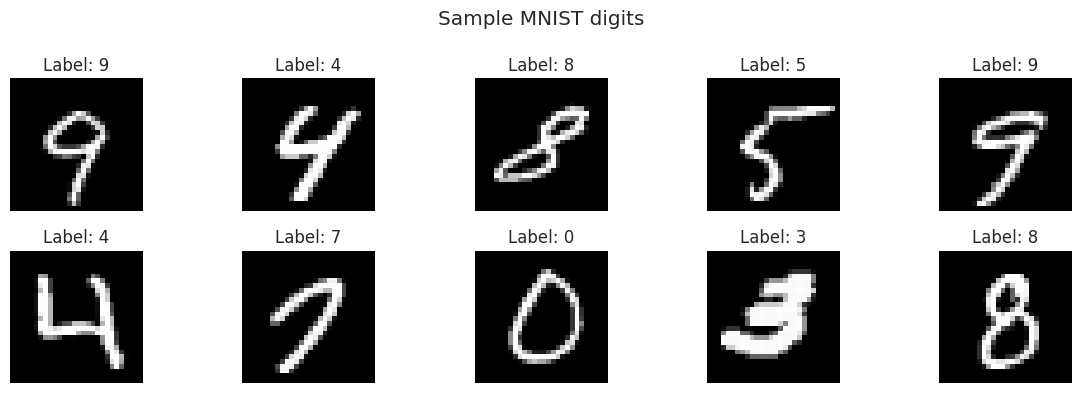

In [2]:
print('Loading MNIST (may take a moment on first run)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_raw = mnist.data.astype(np.float32)   # shape (70000, 784)
y_raw = mnist.target.astype(int)        # shape (70000,)

# Use 10,000 samples for reasonable training time
idx = np.random.choice(len(X_raw), 10000, replace=False)
X_raw, y_raw = X_raw[idx], y_raw[idx]

# Normalize to [0, 1]
X_norm = X_raw / 255.0

# One-hot encode labels
def one_hot(y, n_classes=10):
    oh = np.zeros((len(y), n_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

Y_oh = one_hot(y_raw)

X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X_norm, Y_oh, y_raw, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Visualise some digits
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST digits')
plt.tight_layout()
plt.show()

## 4. Neural Network Implementation

In [3]:
class NeuralNetwork:
    """Fully-connected neural network implemented from scratch using NumPy."""

    def __init__(self, layer_sizes: list):
        """
        Initialise weights and biases using He initialisation.
        He init: W ~ N(0, sqrt(2 / n_in)) — works well with ReLU.
        """
        self.layer_sizes = layer_sizes
        self.n_layers    = len(layer_sizes) - 1  # number of weight layers

        self.W = []  # weight matrices
        self.b = []  # bias vectors

        for i in range(self.n_layers):
            n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
            # He initialisation
            self.W.append(np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in))
            self.b.append(np.zeros((n_out, 1)))

    # ── Activation functions ────────────────────────────────────────────────

    def relu(self, z):
        """Rectified Linear Unit: max(0, z)"""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Derivative of ReLU: 1 if z > 0 else 0"""
        return (z > 0).astype(float)

    def softmax(self, z):
        """
        Numerically stable softmax.
        Subtract max before exponentiation to prevent overflow.
        """
        z_shifted = z - z.max(axis=0, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / exp_z.sum(axis=0, keepdims=True)

    # ── Forward pass ────────────────────────────────────────────────────────

    def forward(self, X: np.ndarray):
        """
        Forward pass through the network.
        X shape: (n_features, batch_size)  [column vectors]
        Returns dict of activations {a0, z1, a1, z2, a2, ...}
        """
        cache = {'a0': X}  # input is a^0

        a = X
        for l in range(self.n_layers):
            z = self.W[l] @ a + self.b[l]       # linear: (n_out, batch)
            cache[f'z{l+1}'] = z

            if l < self.n_layers - 1:
                a = self.relu(z)                 # hidden layers: ReLU
            else:
                a = self.softmax(z)              # output layer: Softmax

            cache[f'a{l+1}'] = a

        return cache

    # ── Loss ────────────────────────────────────────────────────────────────

    def compute_loss(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        """
        Cross-entropy loss.
        y_hat: (n_classes, batch) probabilities
        y:     (n_classes, batch) one-hot labels
        """
        batch_size = y.shape[1]
        # Clip to avoid log(0)
        eps = 1e-15
        loss = -np.sum(y * np.log(np.clip(y_hat, eps, 1))) / batch_size
        return float(loss)

    # ── Backward pass ───────────────────────────────────────────────────────

    def backward(self, y: np.ndarray, cache: dict):
        """
        Backpropagation through all layers.
        Returns gradients dW[l] and db[l] for each layer.
        """
        batch_size = y.shape[1]
        grads_W = [None] * self.n_layers
        grads_b = [None] * self.n_layers

        # Output layer delta: d(CE)/d(softmax_input) = y_hat - y
        y_hat = cache[f'a{self.n_layers}']
        delta = y_hat - y  # (n_classes, batch)

        for l in reversed(range(self.n_layers)):
            a_prev = cache[f'a{l}']         # activation from previous layer

            # Weight gradient: delta @ a_prev^T, averaged over batch
            grads_W[l] = (delta @ a_prev.T) / batch_size
            grads_b[l] = delta.mean(axis=1, keepdims=True)

            if l > 0:
                # Propagate delta to previous layer
                z_prev = cache[f'z{l}']
                delta  = (self.W[l].T @ delta) * self.relu_derivative(z_prev)

        return grads_W, grads_b

    # ── Parameter update ────────────────────────────────────────────────────

    def update_params(self, grads_W, grads_b, lr: float):
        """Gradient descent step."""
        for l in range(self.n_layers):
            self.W[l] -= lr * grads_W[l]
            self.b[l] -= lr * grads_b[l]

    # ── Training loop ───────────────────────────────────────────────────────

    def train(self, X, Y, epochs=100, lr=0.1, batch_size=64, print_every=10):
        """
        Mini-batch gradient descent.
        X, Y are (n_samples, n_features) and (n_samples, n_classes).
        We transpose internally since forward() expects column vectors.
        """
        n = X.shape[0]
        history = []

        for epoch in range(1, epochs + 1):
            # Shuffle data each epoch
            perm   = np.random.permutation(n)
            X_shuf = X[perm]
            Y_shuf = Y[perm]
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, batch_size):
                Xb = X_shuf[start:start+batch_size].T  # (features, batch)
                Yb = Y_shuf[start:start+batch_size].T  # (classes,  batch)

                cache        = self.forward(Xb)
                loss         = self.compute_loss(cache[f'a{self.n_layers}'], Yb)
                grads_W, grads_b = self.backward(Yb, cache)
                self.update_params(grads_W, grads_b, lr)

                epoch_loss += loss
                n_batches  += 1

            avg_loss = epoch_loss / n_batches
            history.append(avg_loss)

            if epoch % print_every == 0:
                acc = self.accuracy(X, Y)
                print(f'Epoch {epoch:>4d}/{epochs}  loss={avg_loss:.4f}  acc={acc:.4f}')

        return history

    # ── Inference ───────────────────────────────────────────────────────────

    def predict(self, X):
        """Return predicted class indices."""
        cache = self.forward(X.T)
        y_hat = cache[f'a{self.n_layers}']  # (n_classes, n_samples)
        return y_hat.argmax(axis=0)

    def accuracy(self, X, Y_oh):
        """Accuracy given one-hot Y."""
        y_pred = self.predict(X)
        y_true = Y_oh.argmax(axis=1)
        return (y_pred == y_true).mean()


print('NeuralNetwork class defined.')

NeuralNetwork class defined.


## 5. Train the Network

In [4]:
# Network: 784 → 128 → 64 → 10
nn = NeuralNetwork(layer_sizes=[784, 128, 64, 10])

print('Training neural network (100 epochs)...')
history = nn.train(
    X_train, Y_train,
    epochs=100,
    lr=0.1,
    batch_size=64,
    print_every=10
)

final_train_acc = nn.accuracy(X_train, Y_train)
final_test_acc  = nn.accuracy(X_test,  Y_test)
print(f'\nFinal train accuracy: {final_train_acc:.4f}')
print(f'Final test  accuracy: {final_test_acc:.4f}')

Training neural network (100 epochs)...
Epoch   10/100  loss=0.0884  acc=0.9844
Epoch   20/100  loss=0.0207  acc=0.9980
Epoch   30/100  loss=0.0066  acc=1.0000
Epoch   40/100  loss=0.0036  acc=1.0000
Epoch   50/100  loss=0.0024  acc=1.0000
Epoch   60/100  loss=0.0018  acc=1.0000
Epoch   70/100  loss=0.0014  acc=1.0000
Epoch   80/100  loss=0.0011  acc=1.0000
Epoch   90/100  loss=0.0009  acc=1.0000
Epoch  100/100  loss=0.0008  acc=1.0000

Final train accuracy: 1.0000
Final test  accuracy: 0.9530


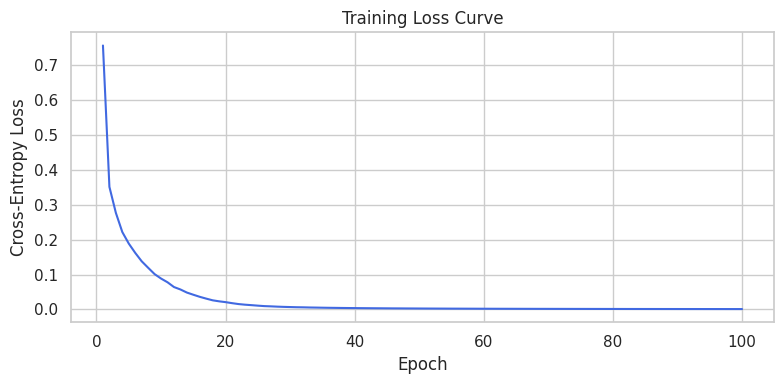

In [5]:
# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history)+1), history, color='royalblue')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.tight_layout()
plt.show()

## 6. Evaluation

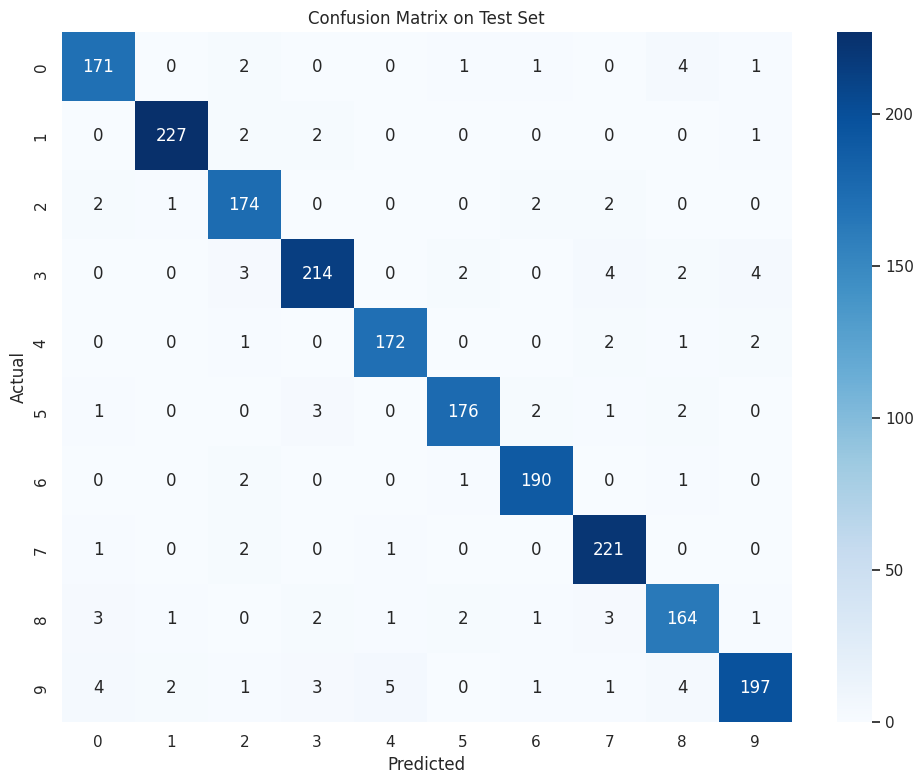

In [6]:
from sklearn.metrics import confusion_matrix

y_pred_test = nn.predict(X_test)
y_true_test = Y_test.argmax(axis=1)

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

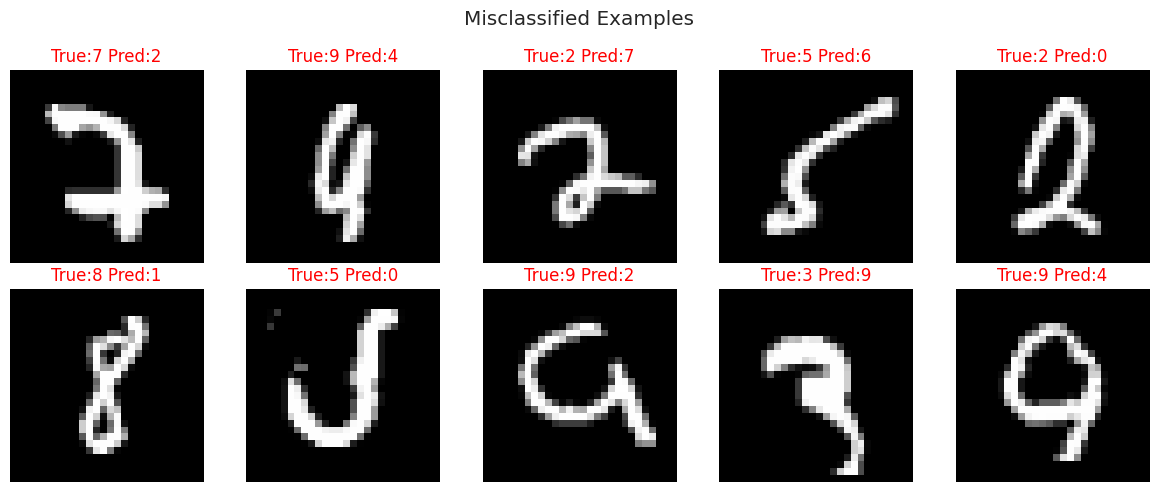

In [7]:
# Visualise misclassified examples
wrong_idx = np.where(y_pred_test != y_true_test)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(wrong_idx):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'True:{y_true_test[idx]} Pred:{y_pred_test[idx]}', color='red')
    ax.axis('off')
plt.suptitle('Misclassified Examples')
plt.tight_layout()
plt.show()

## Summary

We built a neural network **from scratch** using only NumPy, implementing:

| Component | Implementation |
|---|---|
| Forward pass | Matrix multiply + bias + activation |
| Softmax | Numerically stable |
| Loss | Cross-entropy |
| Backprop | Chain rule for all layers |
| Update | Mini-batch gradient descent |

**Key insight**: The Softmax + Cross-Entropy gradient is simply $\hat{p} - y$, which is why this pairing is so commonly used — it's computationally simple and numerically stable.